# On-Device AI: TinyLlama Model Compression

TinyLlama-1.1B 모델에 프루닝과 양자화를 적용하고, 압축 전후의 Perplexity와 생성 품질을 직접 분석합니다.

| Part | 내용 | 핵심 |
|------|------|------|
| Part 0 | Setting | 환경 설정, 모델 로드, Baseline 측정 |
| Part 1 | Pruning | Unstructured, Structured, N:M |
| Part 2 | Quantization | Symmetric, Asymmetric, 비트폭 분석 |
| Part 3 | Combined + Pareto | GPTQ+SparseGPT, config 기반 압축 탐색, Pareto 분석 |


# ⚙️ Part 0. Setting

GPU 런타임에서 실행하세요 (TinyLlama-1.1B FP16, 단일 GPU면 충분).

Kaggle
- Settings > Accelerator > P100 or GPU T4 x2
- Settings > Internet > ON (모델/데이터 다운로드에 필요, 휴대폰 인증 계정만 가능)
- 설정 후 Restart & Run All

In [8]:
!pip install -q -U transformers accelerate datasets sentencepiece ipywidgets

In [9]:
# 실행만 (수정x)
import torch, torch.nn as nn, math, random, gc, time
import numpy as np
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

@torch.no_grad()
def compute_perplexity(model, eval_tokens, max_length=512, stride=256):
    """Sliding-window perplexity over a 1D tensor of token ids. Lower is better."""
    model.eval()
    ids = eval_tokens.squeeze()
    nlls, total = [], 0
    for begin in range(0, len(ids) - 1, stride):
        end = min(begin + max_length, len(ids))
        tgt_len = end - begin - 1
        chunk = ids[begin:end].unsqueeze(0).to(model.device)
        labels = chunk.clone()
        if begin > 0:
            labels[:, :-tgt_len] = -100
        loss = model(chunk, labels=labels).loss
        nlls.append(loss * tgt_len)
        total += tgt_len
        if end == len(ids):
            break
    return torch.exp(torch.stack(nlls).sum() / total).item()

@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new_tokens=80, do_sample=True):
    chat = f"<|user|>\n{prompt}</s>\n<|assistant|>\n"
    ids = tokenizer(chat, return_tensors='pt').input_ids.to(model.device)
    out = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=do_sample,
                         temperature=0.7, top_p=0.9,
                         pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True)

def _sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

@torch.no_grad()
def benchmark_latency(model, tokenizer, prompt, new_tokens=64, warmup=1):
    """Prefill latency, decode throughput (greedy) for the current model state."""
    chat = f"<|user|>\n{prompt}</s>\n<|assistant|>\n"
    ids = tokenizer(chat, return_tensors='pt').input_ids.to(model.device)
    for _ in range(warmup):
        model.generate(ids, max_new_tokens=8, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    _sync()
    t0 = time.time()
    model(ids)
    _sync()
    prefill_ms = (time.time() - t0) * 1000

    t0 = time.time()
    out = model.generate(ids, max_new_tokens=new_tokens, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id)
    _sync()
    dt = time.time() - t0
    gen = out.shape[1] - ids.shape[1]
    return {'prefill_ms': prefill_ms, 'decode_tok_s': gen / dt if dt > 0 else 0.0,
            'gen_tokens': gen, 'decode_s': dt}

def model_info(model):
    total = sum(p.numel() for p in model.parameters())
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
    return total, size_mb

def gpu_mem():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**2
    return 0.0

def save_weights(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def restore_weights(model, state):
    own = dict(model.named_parameters())
    own.update(dict(model.named_buffers()))
    for k, v in state.items():
        p = own.get(k)
        if p is not None:
            p.data.copy_(v.to(p.device))
    model.eval()

def compute_layerwise_sparsity(model):
    out = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            w = m.weight.detach()
            n = w.numel()
            out.append((name, (w == 0).sum().item() / n if n else 0.0, n))
    return out

def compute_global_sparsity(model):
    total = zeros = 0
    for m in model.modules():
        if isinstance(m, nn.Linear):
            w = m.weight.detach()
            total += w.numel()
            zeros += (w == 0).sum().item()
    return zeros, total, (zeros / total if total else 0.0)

import matplotlib as mpl

PALETTE = {
    'unstruct': '#e4572e', 'head': '#2e86de', 'neuron': '#17a673', 'nm': '#8e5cd9',
    'baseline': '#9aa0a6', 'sym': '#2e86de', 'asym': '#e4572e', 'bar': '#4c78a8',
    'accent': '#e4572e', 'pareto': '#e4572e', 'dom': '#a9bcd6', 'grid': '#e8e8e8',
}

def set_plot_style():
    """Apply one clean, consistent matplotlib look for the whole notebook."""
    mpl.rcParams.update({
        'figure.dpi': 120, 'savefig.dpi': 120, 'figure.facecolor': 'white',
        'axes.facecolor': 'white', 'axes.edgecolor': '#c8c8c8', 'axes.linewidth': 1.0,
        'axes.grid': True, 'axes.axisbelow': True, 'grid.color': PALETTE['grid'],
        'grid.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
        'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
        'axes.labelsize': 11, 'axes.labelcolor': '#333333', 'xtick.color': '#555555',
        'ytick.color': '#555555', 'xtick.labelsize': 10, 'ytick.labelsize': 10,
        'legend.frameon': True, 'legend.framealpha': 0.92, 'legend.edgecolor': '#dddddd',
        'legend.fontsize': 9.5, 'lines.linewidth': 2.4, 'lines.markersize': 7,
        'image.cmap': 'RdBu_r',
    })

def plot_weight_heatmap(model, layer_name, title=None, ax=None, cmap='RdBu_r'):
    for name, m in model.named_modules():
        if name == layer_name and hasattr(m, 'weight'):
            w = m.weight.detach().cpu().float().numpy()
            if ax is None:
                _, ax = plt.subplots(figsize=(9, 5))
            vmax = max(abs(w.min()), abs(w.max()))
            im = ax.imshow(w, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax, interpolation='nearest')
            ax.set_title(title or layer_name); ax.grid(False)
            ax.set_xlabel('input'); ax.set_ylabel('output')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            return ax

def plot_sparsity_dashboard(model, title='Layer-wise Sparsity'):
    data = [(n, s) for n, s, _ in compute_layerwise_sparsity(model) if 'layers.' in n]
    if not data:
        return
    names = [n.replace('model.layers.', 'L') for n, _ in data]
    sp = [s * 100 for _, s in data]
    fig, ax = plt.subplots(figsize=(12, max(6, len(names) * 0.17)))
    colors = [PALETTE['accent'] if s > 50 else PALETTE['head'] for s in sp]
    ax.barh(range(len(names)), sp, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=5)
    ax.set_xlabel('Sparsity (%)'); ax.set_title(title)
    ax.set_xlim(0, 100); ax.invert_yaxis(); ax.grid(True, alpha=0.4, axis='x')
    _, _, gl = compute_global_sparsity(model)
    ax.axvline(gl * 100, color=PALETTE['neuron'], ls='--', lw=2, label=f'Global {gl:.1%}')
    ax.legend(loc='lower right'); fig.tight_layout(); plt.show()

def plot_quant_error_heatmap(w_orig, w_quant, layer_name, figsize=(15, 4)):
    err = (w_orig - w_quant).numpy()
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    vmax = max(abs(w_orig.numpy().min()), abs(w_orig.numpy().max())) or 1.0
    for ax, data, t in zip(axes[:2], [w_orig.numpy(), w_quant.numpy()], ['Original', 'Quantized']):
        im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
        ax.set_title(t); ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    emax = max(abs(err.min()), abs(err.max())) or 1.0
    im = axes[2].imshow(err, aspect='auto', cmap='coolwarm', vmin=-emax, vmax=emax, interpolation='nearest')
    axes[2].set_title(f'Error  (MSE = {np.mean(err**2):.2e})'); axes[2].grid(False)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.suptitle(f'Quantization Error · {layer_name}', fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

def _downsample(t, max_side=620):
    s0 = max(1, t.shape[0] // max_side)
    s1 = max(1, t.shape[1] // max_side)
    return t[::s0, ::s1]

def plot_pruning_view(w_orig, w_pruned, title=''):
    """Original weights, kept/pruned mask, and the magnitude distribution with
    the pruning cutoff. Uses the full weight matrix (downsampled for display)."""
    o = w_orig.detach().cpu().float()
    p = w_pruned.detach().cpu().float()
    actual_sp = (p == 0).float().mean().item()
    od = _downsample(o).numpy()
    mask = (_downsample(p) != 0).float().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
    vmax = float(np.percentile(np.abs(od), 99.0)) or (float(np.abs(od).max()) or 1.0)
    im = axes[0].imshow(od, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
    axes[0].set_title('Original weights (color clipped @99pct)'); axes[0].grid(False)
    axes[0].set_xlabel('input'); axes[0].set_ylabel('output')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, extend='both')
    axes[1].imshow(mask, aspect='auto', cmap='binary_r', vmin=0, vmax=1, interpolation='nearest')
    axes[1].set_title(f'Kept (white) / pruned (black)  ·  {actual_sp:.0%} pruned')
    axes[1].set_xlabel('input'); axes[1].set_ylabel('output'); axes[1].grid(False)

    x = o.flatten()
    if x.numel() > 200000:
        x = x[torch.randperm(x.numel())[:200000]]
    x = x.numpy()
    pruned_mag = o.abs()[p == 0]
    thr = pruned_mag.max().item() if pruned_mag.numel() > 0 else 0.0
    xlim = float(np.percentile(np.abs(x), 99.7)) or 1.0
    axes[2].hist(x, bins=160, range=(-xlim, xlim), color=PALETTE['bar'], alpha=0.9)
    axes[2].axvspan(-thr, thr, color='0.55', alpha=0.45, label=f'pruned: |w| <= {thr:.3g}')
    axes[2].axvline(-thr, color='0.35', lw=1.6)
    axes[2].axvline(thr, color='0.35', lw=1.6)
    axes[2].set_xlim(-xlim, xlim)
    axes[2].set_xlabel('weight value'); axes[2].set_ylabel('count')
    axes[2].set_title('Weight distribution (gray = pruned)'); axes[2].legend()
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


def plot_quant_by_bits(w, bits_list=(2, 3, 4, 8)):
    """Top: quantization transfer (staircase, 2^b levels). Bottom: value
    distribution. Lower bit width -> fewer levels, coarser steps."""
    w = w.detach().cpu().float().flatten()
    if w.numel() > 40000:
        w = w[torch.randperm(w.numel())[:40000]]
    x = w.numpy()
    order = np.argsort(x)
    a = w.abs().max().item() or 1.0
    fig, axes = plt.subplots(2, len(bits_list), figsize=(3.5 * len(bits_list), 6.6), sharex='col')
    for j, b in enumerate(bits_list):
        qn, qp = -(2 ** (b - 1)), 2 ** (b - 1) - 1
        s = (2 * a) / (qp - qn)
        q = (torch.clamp(torch.round(w / s), qn, qp) * s).numpy()
        axes[0, j].plot([x.min(), x.max()], [x.min(), x.max()], '--', color='#bbbbbb', lw=1.2)
        axes[0, j].plot(x[order], q[order], color=PALETTE['accent'], lw=2)
        axes[0, j].set_title(f'{b}-bit · {2 ** b} levels')
        axes[0, j].set_xlabel('original'); axes[0, j].set_ylabel('quantized' if j == 0 else '')
        axes[1, j].hist(q, bins=60, color=PALETTE['bar'], alpha=0.9)
        axes[1, j].set_yscale('log'); axes[1, j].set_xlabel('weight value')
        axes[1, j].set_ylabel('count (log)' if j == 0 else '')
    fig.suptitle('Quantization by bit width — transfer (top) · value distribution (bottom)',
                 fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

set_seed(42)
set_plot_style()
device = get_device()
print('device:', device)

device: cuda


In [10]:
# TinyLlama 로드 (FP16, 단일 GPU)
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(device)
model.eval()

total_params, size_mb = model_info(model)
print(f"parameters : {total_params:,} ({total_params/1e9:.2f}B)")
print(f"size (FP16): {size_mb:.0f} MB")
print(f"layers     : {model.config.num_hidden_layers}")
print(f"hidden/head: {model.config.hidden_size} / {model.config.num_attention_heads} heads "
      f"({model.config.num_key_value_heads} kv-heads, GQA)")

print("\ndecoder layer 0 Linear sublayers:")
for name, m in model.model.layers[0].named_modules():
    if isinstance(m, nn.Linear):
        print(f"  {name:22s} {list(m.weight.shape)}")
print(f"GPU memory: {gpu_mem():.0f} MB")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

parameters : 1,100,048,384 (1.10B)
size (FP16): 2098 MB
layers     : 22
hidden/head: 2048 / 32 heads (4 kv-heads, GQA)

decoder layer 0 Linear sublayers:
  self_attn.q_proj       [2048, 2048]
  self_attn.k_proj       [256, 2048]
  self_attn.v_proj       [256, 2048]
  self_attn.o_proj       [2048, 2048]
  mlp.gate_proj          [5632, 2048]
  mlp.up_proj            [5632, 2048]
  mlp.down_proj          [2048, 5632]
GPU memory: 2108 MB


In [11]:
# Baseline: Perplexity + 생성 + 가중치 백업
from datasets import load_dataset

wikitext = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='test')
eval_text = '\n\n'.join([t for t in wikitext['text'] if len(t) > 50][:80])
eval_tokens = tokenizer(eval_text, return_tensors='pt').input_ids[:, :2048]
print(f"eval tokens: {eval_tokens.shape[1]:,}")

baseline_ppl = compute_perplexity(model, eval_tokens)
print(f"baseline perplexity: {baseline_ppl:.2f}")

test_prompt = "What is model compression in deep learning?"
print(f"\nprompt: {test_prompt}")
print(f"output: {generate_text(model, tokenizer, test_prompt)}")

lat = benchmark_latency(model, tokenizer, test_prompt)
print(f"\nlatency: prefill {lat['prefill_ms']:.0f} ms | decode {lat['decode_tok_s']:.1f} tok/s "
      f"({lat['gen_tokens']} tokens)")

original_state = save_weights(model)   # sweep / 실험 복원용 (CPU)
print(f"weights backed up. GPU memory: {gpu_mem():.0f} MB")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (13999 > 2048). Running this sequence through the model will result in indexing errors


eval tokens: 2,048


[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


baseline perplexity: 10.31

prompt: What is model compression in deep learning?


[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


output: Model compression in deep learning refers to the process of reducing the size of deep learning models without compromising their performance. It involves reducing the number of parameters (weights) and the size of the network structure while maintaining the same level of accuracy and performance. Model compression techniques aim to achieve this by using techniques such as layer pruning, quantization, and neural architecture search (NAS) to


[transformers] Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



latency: prefill 34 ms | decode 33.6 tok/s (64 tokens)
weights backed up. GPU memory: 2108 MB


In [12]:
# 인터랙티브 위젯: 토큰 단위 실시간 스트리밍 (단일 채팅 + 원본/압축 좌우 동시 비교)
import ipywidgets as widgets
from IPython.display import display
import threading, copy, gc, time, ctypes
from transformers import TextIteratorStreamer

try:                                    # Colab에서 ipywidgets 렌더링 보장
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
except Exception:
    pass

try:                                    # glibc arena를 OS에 반납해 RSS 누적 완화 (Linux)
    _libc = ctypes.CDLL("libc.so.6")
    def _trim():
        try:
            _libc.malloc_trim(0)
        except Exception:
            pass
except Exception:
    def _trim():
        pass

def _panel(title, color, body, foot='', cursor=False):
    cur = (f'<span style="color:{color}">&#9612;</span>') if cursor else ''
    body = body or '<span style="color:#aaa">(대기 중)</span>'
    foot_html = (f'<div style="margin-top:8px;color:#8a8a8a;font-size:11px;'
                 f'border-top:1px solid #eee;padding-top:6px">{foot}</div>') if foot else ''
    return (f'<div style="border:1px solid #e6e6e6;border-radius:10px;background:#fff;'
            f'box-shadow:0 1px 4px rgba(0,0,0,.07);overflow:hidden">'
            f'<div style="background:{color};color:#fff;padding:8px 12px;font-weight:600;'
            f'font-size:13px">{title}</div>'
            f'<div style="padding:12px;font-family:ui-monospace,SFMono-Regular,Menlo,Consolas,'
            f'monospace;font-size:12.5px;line-height:1.6;color:#222;white-space:pre-wrap;'
            f'min-height:96px">{body}{cur}</div>{foot_html}</div>')

def _make_streamer():
    return TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

# 경량 PPL 배지용: 짧은 고정 텍스트로 빠르게 perplexity 측정 (Compare 좌우 패널 footer에 표시)
_PPL_PROBE_TEXT = ("On-device AI runs neural networks directly on local hardware such as phones "
                   "and embedded chips. Model compression shrinks memory and computation so that "
                   "large models fit within these tight resource budgets.")
_ppl_probe_ids = tokenizer(_PPL_PROBE_TEXT, return_tensors='pt').input_ids

def _light_ppl(m):
    """짧은 고정 텍스트로 빠르게 PPL 측정 (Compare footer 배지)."""
    with torch.no_grad():
        return compute_perplexity(m, _ppl_probe_ids)

def _stream_worker(m, ids, state, key, do_sample):
    """별도 스레드에서 generate를 돌리며 토큰을 state에 누적."""
    streamer = _make_streamer()
    kw = dict(input_ids=ids, max_new_tokens=state['n'], do_sample=do_sample,
              pad_token_id=tokenizer.eos_token_id, streamer=streamer)
    if do_sample:
        kw.update(temperature=0.7, top_p=0.9)
    th = threading.Thread(target=m.generate, kwargs=kw)
    t0 = time.time(); th.start(); ntok = 0; t_first = None
    for piece in streamer:
        if t_first is None:
            t_first = time.time()
        state[key] += piece; ntok += 1
    th.join()
    dt = max(time.time() - t0, 1e-6)
    ttft = (t_first - t0) * 1000 if t_first else 0.0
    ppl = _light_ppl(m)                                   # 경량 PPL 배지
    state['foot_' + key] = (f"PPL {ppl:.2f}  ·  {ntok} tokens · {ntok / dt:.1f} tok/s "
                            f"· first token {ttft:.0f} ms")
    state['done_' + key] = True

def chat_widget(value='Explain on-device AI in one sentence.', title='TinyLlama', color='#16a085', ensure_state=None):
    box = widgets.Textarea(value=value, layout=widgets.Layout(width='99%', height='52px'))
    btn = widgets.Button(description='Generate', button_style='primary',
                         layout=widgets.Layout(width='150px'))
    out = widgets.HTML(_panel(title, color, ''))

    def run(_):
        prompt = box.value.strip()
        if not prompt:
            return
        btn.disabled = True; btn.description = 'generating...'
        chat = f"<|user|>\n{prompt}</s>\n<|assistant|>\n"
        if ensure_state is not None:                 # 클릭마다 압축 가중치 재적용 → 실행 순서와 무관하게 항상 '압축 모델'
            restore_weights(model, ensure_state)
        ids = tokenizer(chat, return_tensors='pt').input_ids.to(model.device)
        streamer = _make_streamer()
        kw = dict(input_ids=ids, max_new_tokens=256, do_sample=True, temperature=0.7, top_p=0.9,
                  pad_token_id=tokenizer.eos_token_id, streamer=streamer)
        th = threading.Thread(target=model.generate, kwargs=kw)
        t0 = time.time(); acc = ''; ntok = 0; last = 0.0
        try:
            th.start()
            for piece in streamer:                   # 토큰마다가 아니라 ~16fps로만 위젯 갱신
                acc += piece; ntok += 1
                if time.time() - last > 0.06:
                    out.value = _panel(title, color, acc, '', cursor=True); last = time.time()
            th.join()
            dt = max(time.time() - t0, 1e-6)
            out.value = _panel(title, color, acc, f'{ntok} tokens · {ntok / dt:.1f} tok/s')
        finally:
            del ids, streamer, th                    # 생성마다 임시 객체 해제 + RSS 반납
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            _trim()
            btn.disabled = False; btn.description = 'Generate'

    btn.on_click(run)
    display(widgets.VBox([box, btn, out]))


_cmp_model = None


def _get_cmp_model():
    """원본과 비교할 모델을 한 번만 만들어 재사용 (클릭마다 deepcopy/재로드하지 않음)."""
    global _cmp_model
    if _cmp_model is None:
        _cmp_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.float16).to(device).eval()
    return _cmp_model


def compare_frame(compress_fn, label, new_tokens=256):
    """동일 입력에 대해 Original(FP16) vs 압축 모델을 좌우에서 동시에 토큰 스트리밍 비교.
    원본 model은 그대로 두고, 재사용 가능한 비교용 모델에만 압축을 적용한다."""
    box = widgets.Textarea(value='Explain model quantization in simple terms.',
                           layout=widgets.Layout(width='99%', height='52px'))
    btn = widgets.Button(description='Compare', button_style='primary',
                         layout=widgets.Layout(width='150px'))
    left, right = widgets.HTML(), widgets.HTML()
    grid = widgets.GridBox([left, right], layout=widgets.Layout(
        grid_template_columns='1fr 1fr', grid_gap='12px', width='100%'))
    left.value = _panel('Original (FP16)', PALETTE['head'], '')
    right.value = _panel(label, PALETTE['accent'], '')

    def run(_):
        prompt = box.value.strip()
        if not prompt:
            return
        btn.disabled = True; btn.description = 'generating...'
        restore_weights(model, original_state)
        m_cmp = _get_cmp_model()                      # deepcopy 대신 재사용 모델
        restore_weights(m_cmp, original_state)
        compress_fn(m_cmp); m_cmp.eval()
        chat = f"<|user|>\n{prompt}</s>\n<|assistant|>\n"
        ids_o = tokenizer(chat, return_tensors='pt').input_ids.to(model.device)
        ids_c = tokenizer(chat, return_tensors='pt').input_ids.to(m_cmp.device)
        state = {'n': new_tokens, 'L': '', 'R': '', 'foot_L': '', 'foot_R': '',
                 'done_L': False, 'done_R': False}
        wl = threading.Thread(target=_stream_worker, args=(model, ids_o, state, 'L', False))
        wr = threading.Thread(target=_stream_worker, args=(m_cmp, ids_c, state, 'R', False))
        try:
            wl.start(); wr.start()
            while not (state['done_L'] and state['done_R']):    # 메인 스레드에서 양쪽 갱신
                left.value = _panel('Original (FP16)', PALETTE['head'], state['L'],
                                    state['foot_L'], cursor=not state['done_L'])
                right.value = _panel(label, PALETTE['accent'], state['R'],
                                     state['foot_R'], cursor=not state['done_R'])
                time.sleep(0.05)
            wl.join(); wr.join()
            left.value = _panel('Original (FP16)', PALETTE['head'], state['L'], state['foot_L'])
            right.value = _panel(label, PALETTE['accent'], state['R'], state['foot_R'])
        finally:
            del ids_o, ids_c, wl, wr, state           # 비교 모델(m_cmp)은 유지·재사용
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            _trim()
            btn.disabled = False; btn.description = 'Compare'

    btn.on_click(run)
    display(widgets.VBox([box, btn, grid]))


chat_widget()


# ✂️ Part 1. Pruning

Pruning은 중요도가 낮은 가중치를 0으로 만들어 모델을 희소화(sparsify)합니다.

| 방식 | 단위 | 실제 하드웨어 이득 |
|------|------|-------------------|
| Unstructured | 개별 가중치 | 제한적 (sparse 포맷 필요) |
| Structured | Attention head / MLP neuron | 큼 (행렬 자체가 작아짐) |
| N:M | M개 중 N개 유지 | 큼 (전용 sparse tensor core) |

embed_tokens와 lm_head는 프루닝에서 제외합니다.


## 1-1. Unstructured Magnitude Pruning

절대값이 작은 가중치부터 제거합니다. 각 Linear 레이어를 목표 sparsity까지 독립적으로 희소화합니다.

실습: 아래 TODO를 채워 magnitude pruning을 완성하세요.


In [13]:
####################################################################
pruning_sparsity = 0.5      # 제거할 가중치 비율 (0.0~1.0, 예: 0.5 = 50%)
####################################################################

@torch.no_grad()
def apply_magnitude_pruning(model, sparsity):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and 'lm_head' not in name and 'embed' not in name:
            weight = module.weight.data

            # TODO 1: 가중치의 절대값 (torch.abs)
            abs_weights = torch.abs(weight)

            # TODO 2: 제거할 개수 = 전체 원소 수 * sparsity (int)
            num_prune = int(weight.numel() * sparsity)

            if num_prune == 0:
                continue

            # TODO 3: 임계값 = 정렬된 절대값에서 num_prune 번째 값
            threshold = torch.sort(abs_weights.flatten())[0][num_prune - 1]

            # TODO 4: 임계값 이하를 0으로
            mask = abs_weights <= threshold
            weight[mask] = 0

apply_magnitude_pruning(model, pruning_sparsity)
ppl_pruned = compute_perplexity(model, eval_tokens)
print(f"baseline PPL : {baseline_ppl:.2f}")
print(f"pruned   PPL : {ppl_pruned:.2f} (delta {ppl_pruned - baseline_ppl:+.2f})")
restore_weights(model, original_state)

baseline PPL : 10.31
pruned   PPL : 27.81 (delta +17.50)


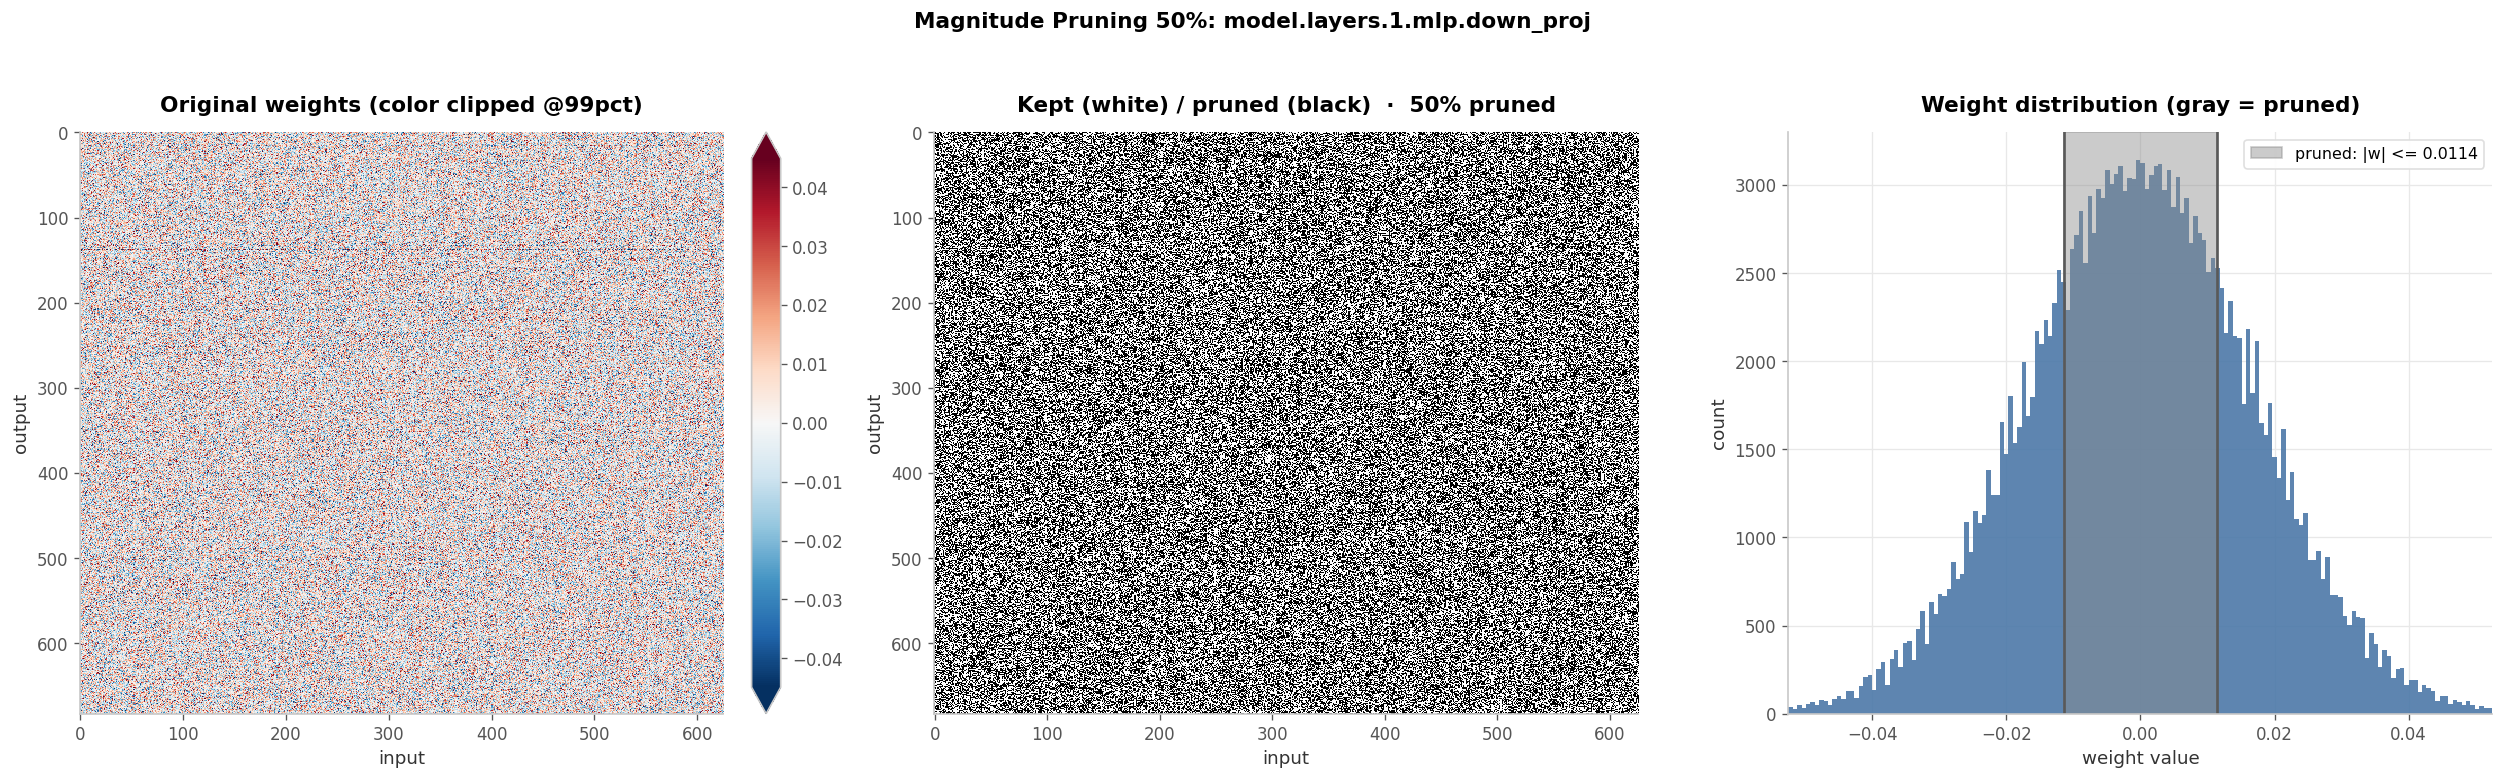

In [14]:
# 프루닝 시각화: 전체 행렬 기준 마스크 + magnitude 분포(임계값 표시)
####################################################################
layer_viz = 'model.layers.1.mlp.down_proj'   # 시각화할 레이어 (예: ...self_attn.q_proj)
####################################################################
for n, m in model.named_modules():
    if n == layer_viz:
        w_orig = m.weight.detach().cpu().float()
apply_magnitude_pruning(model, pruning_sparsity)
for n, m in model.named_modules():
    if n == layer_viz:
        w_pruned = m.weight.detach().cpu().float()
restore_weights(model, original_state)

plot_pruning_view(w_orig, w_pruned, f'Magnitude Pruning {pruning_sparsity*100:.0f}%: {layer_viz}')

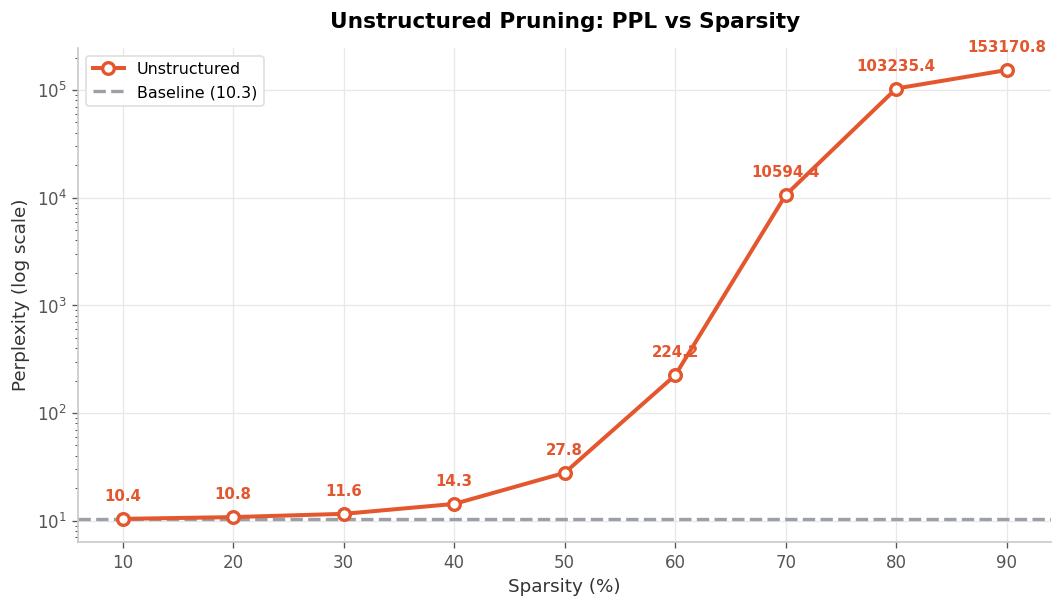

In [15]:
# Sparsity sweep
####################################################################
sparsity_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # 비교할 sparsity 값들
####################################################################
ppl_unstruct = []
for sp in sparsity_levels:
    restore_weights(model, original_state)
    apply_magnitude_pruning(model, sp)
    ppl_unstruct.append(compute_perplexity(model, eval_tokens))
restore_weights(model, original_state)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot([s*100 for s in sparsity_levels], ppl_unstruct, 'o-', color=PALETTE['unstruct'],
        mfc='white', mew=2, label='Unstructured', zorder=3)
ax.axhline(baseline_ppl, color=PALETTE['baseline'], ls='--', lw=2, label=f'Baseline ({baseline_ppl:.1f})')
ax.set_xlabel('Sparsity (%)'); ax.set_ylabel('Perplexity (log scale)'); ax.set_yscale('log')
ax.set_title('Unstructured Pruning: PPL vs Sparsity'); ax.legend()
for s, p in zip(sparsity_levels, ppl_unstruct):
    ax.annotate(f'{p:.1f}', (s*100, p), textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=9, color=PALETTE['unstruct'], fontweight='bold')
fig.tight_layout(); plt.show()

### 🤔 Thinking Exercises
Part 1-1 T1

Q. Magnitude가 큰 가중치가 왜 더 중요하다고 볼 수 있을까요?

답안:

Magnitude가 큰 weight는 입력값과 곱해졌을 때 출력 activation에 더 큰 영향을 줄 가능성이 높다. 반대로 magnitude가 매우 작은 weight는 곱셈 결과가 작기 때문에 최종 출력에 미치는 영향이 상대적으로 작다고 볼 수 있다. 따라서 magnitude pruning에서는 절댓값이 작은 weight를 중요도가 낮은 parameter로 보고 먼저 제거한다. 다만 weight의 크기만으로 중요도를 완벽히 판단할 수는 없으며, 입력 분포나 layer sensitivity에 따라 작은 weight도 중요한 역할을 할 수 있다.

Part 1-1 T2

Q. Unstructured pruning만으로 실제 추론 속도/메모리 이득을 얻기 어려운 이유는?

답안:

Unstructured pruning은 개별 weight를 0으로 만들기 때문에 sparsity는 증가하지만, 행렬의 shape 자체는 그대로 유지된다. 일반 GPU/NPU는 dense matrix multiplication에 최적화되어 있으므로 0인 weight를 자동으로 건너뛰지 못하는 경우가 많다. 또한 sparse format을 사용하려면 index 저장과 irregular memory access overhead가 발생한다. 따라서 parameter 수는 줄어도 실제 latency나 throughput이 크게 개선되지 않을 수 있다.

## 1-2. Structured Pruning

행렬의 행/열(채널)을 통째로 제거하는 방식 (여기서는 0으로 마스킹해 정확도 영향만 측정; 실제 배포 시엔 행렬 차원 자체를 축소해 연산량을 줄임).
- 여기서는 **MLP의 intermediate 뉴런**을 통째로 제거합니다. 뉴런 하나는 `gate_proj`·`up_proj`의 **출력 행**과 `down_proj`의 **입력 열**로 연결돼 있어, 같은 인덱스를 함께 0으로 만들면(coupled) 뉴런이 깔끔히 사라집니다.
- 중요도는 뉴런별 `gate+up` 행의 평균 |W| 로 매겨 낮은 순으로 제거합니다.
- attention(q/k/v/o)·residual 투영은 제외합니다 — magnitude 기준으로 통째로 자르면(재학습 없이) 모델이 곧바로 붕괴하기 때문입니다. (실제 배포 시엔 제거한 뉴런에 대응하는 차원을 실제로 줄여 FLOPs를 절감합니다.)


In [17]:
# Structured pruning — MLP intermediate 뉴런만 (coupled gate/up/down)
@torch.no_grad()
def apply_channel_pruning(model, sparsity):
    for layer in model.model.layers:
        mlp = layer.mlp
        inter = mlp.gate_proj.weight.shape[0]                        # intermediate 뉴런 수
        k = max(1, int(inter * sparsity))

        # 뉴런별 중요도 = gate·up 출력 행의 평균 |W| (행 = 뉴런)
        scores = (mlp.gate_proj.weight.data.abs().mean(dim=1)
                  + mlp.up_proj.weight.data.abs().mean(dim=1))

        # TODO: 중요도가 낮은 k개 뉴런의 인덱스 (topk, largest=False)
        prune = torch.topk(scores, k=k, largest=False).indices

        mlp.gate_proj.weight.data[prune, :] = 0     # 뉴런 입력측(행) 제거
        mlp.up_proj.weight.data[prune, :]   = 0
        mlp.down_proj.weight.data[:, prune] = 0     # 뉴런 출력측(열) 제거

ppl_channel = []
for sp in sparsity_levels:
    restore_weights(model, original_state)
    apply_channel_pruning(model, sp)
    ppl_channel.append(compute_perplexity(model, eval_tokens))

restore_weights(model, original_state)

# 주의: 여기서 sparsity 는 'MLP 뉴런'을 제거한 비율 (attention 은 제외)
print(f"{'Sparsity':>9} | {'Struct (MLP)':>10} | {'Unstruct':>9}")
for i, sp in enumerate(sparsity_levels):
    print(f"{sp*100:>7.0f}%  | {ppl_channel[i]:>10.2f} | {ppl_unstruct[i]:>9.2f}")

 Sparsity | Struct (MLP) |  Unstruct
     10%  |      80.45 |     10.39
     20%  |     160.20 |     10.79
     30%  |     366.47 |     11.56
     40%  |    1007.44 |     14.29
     50%  |    2263.22 |     27.81
     60%  |    8959.46 |    224.23
     70%  |   14560.13 |  10594.39
     80%  |   24025.85 | 103235.43
     90%  |  115872.52 | 153170.83


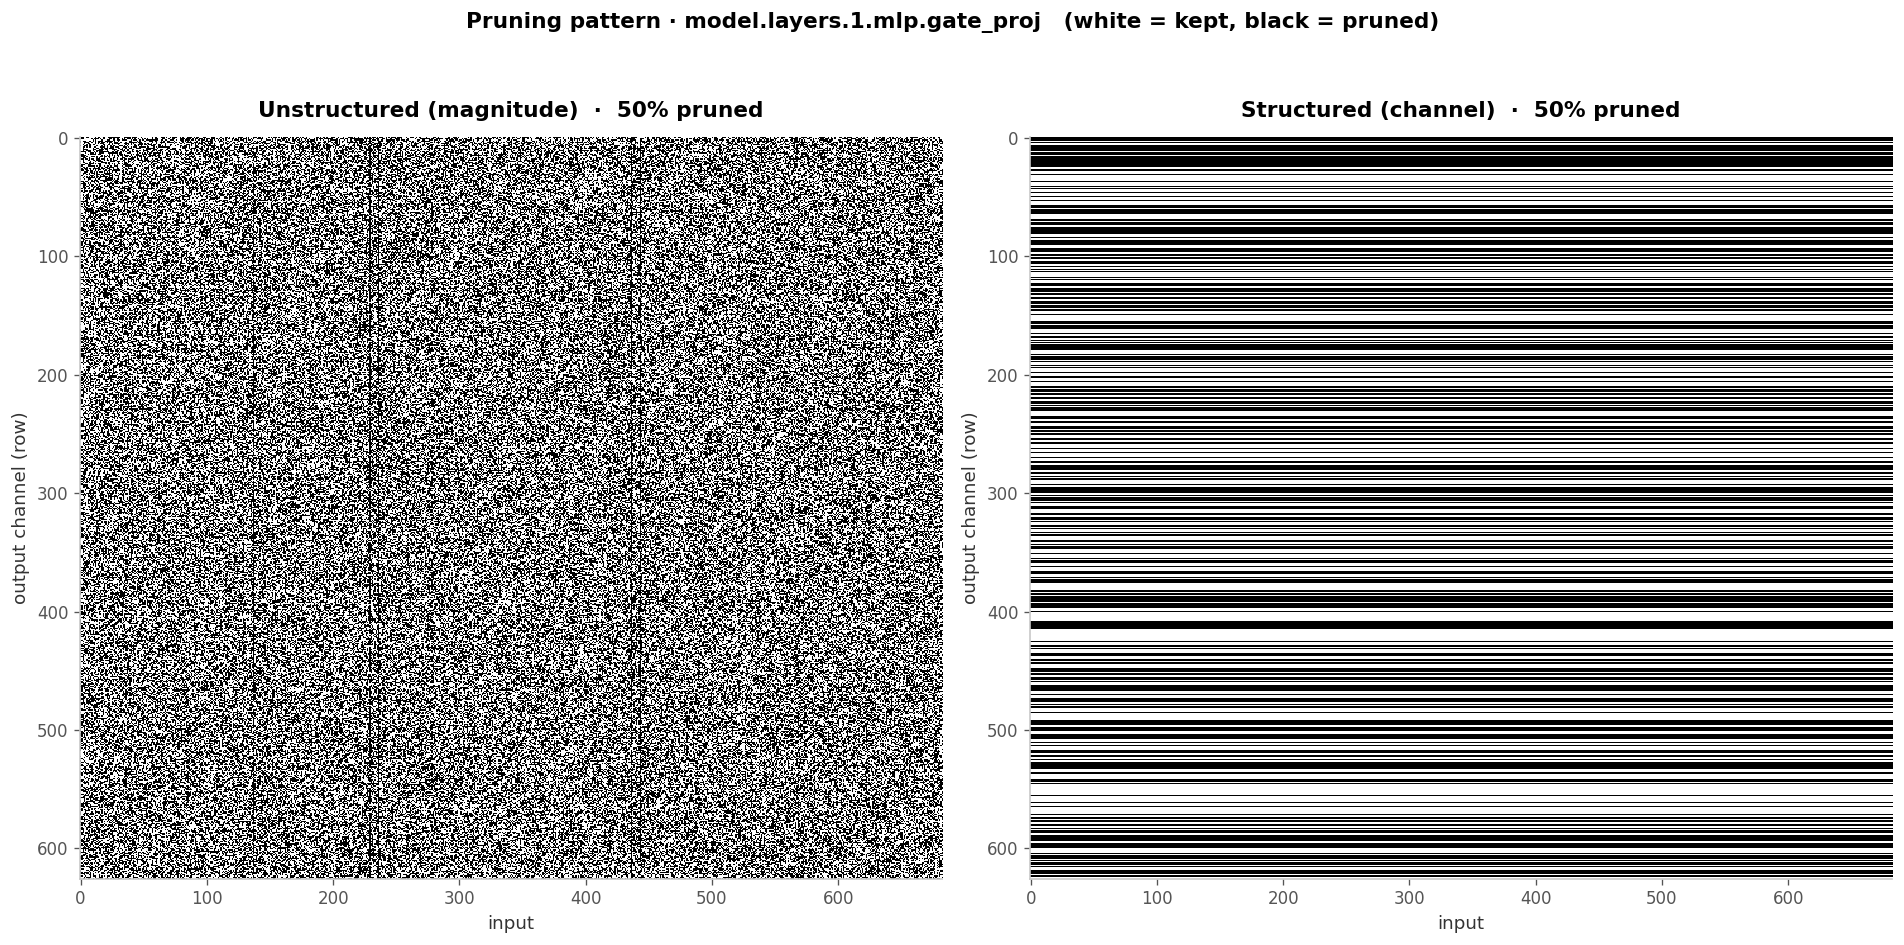

In [18]:
# Unstructured vs Structured: 프루닝 패턴(마스크) 비교
####################################################################
cmp_layer = 'model.layers.1.mlp.gate_proj'   # attention 예: 'model.layers.1.self_attn.q_proj'
cmp_sparsity = 0.5
####################################################################

def _layer_mask(layer_name):
    for n, m in model.named_modules():
        if n == layer_name:
            return (m.weight.detach().cpu() != 0).float().numpy()
    return None

restore_weights(model, original_state); apply_magnitude_pruning(model, cmp_sparsity)
mask_u = _layer_mask(cmp_layer)
restore_weights(model, original_state); apply_channel_pruning(model, cmp_sparsity)
mask_s = _layer_mask(cmp_layer)
restore_weights(model, original_state)

def _ds(a, max_side=620):
    s0 = max(1, a.shape[0] // max_side); s1 = max(1, a.shape[1] // max_side)
    return a[::s0, ::s1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, mask, title in [(axes[0], mask_u, 'Unstructured (magnitude)'),
                        (axes[1], mask_s, 'Structured (channel)')]:
    ax.imshow(_ds(mask), aspect='auto', cmap='binary_r', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'{title}  ·  {1 - mask.mean():.0%} pruned'); ax.grid(False)
    ax.set_xlabel('input'); ax.set_ylabel('output channel (row)')
fig.suptitle(f'Pruning pattern · {cmp_layer}   (white = kept, black = pruned)',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


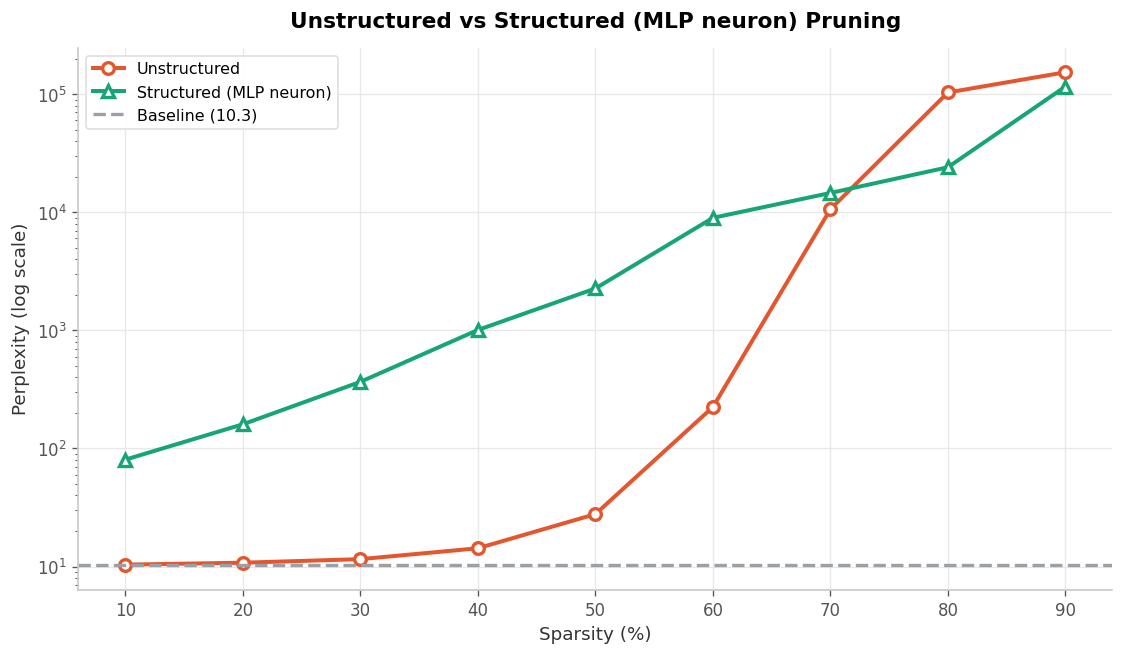

In [19]:
# Unstructured vs Structured (channel)
sp_pct = [s*100 for s in sparsity_levels]
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.plot(sp_pct, ppl_unstruct, 'o-', color=PALETTE['unstruct'], mfc='white', mew=2, label='Unstructured')
ax.plot(sp_pct, ppl_channel, '^-', color=PALETTE['neuron'], mfc='white', mew=2, label='Structured (MLP neuron)')
ax.axhline(baseline_ppl, color=PALETTE['baseline'], ls='--', lw=2, label=f'Baseline ({baseline_ppl:.1f})')
ax.set_xlabel('Sparsity (%)'); ax.set_ylabel('Perplexity (log scale)'); ax.set_yscale('log')
ax.set_title('Unstructured vs Structured (MLP neuron) Pruning'); ax.legend()
fig.tight_layout(); plt.show()


### 🤔 Thinking Exercises
T1) 같은 sparsity에서 structured가 unstructured보다 PPL이 높은(나쁜) 이유는?

T2) 그럼에도 structured pruning이 실제 배포에서 선호되는 이유는?


## 1-3. N:M Pruning

연속한 M개 가중치 중 절대값이 큰 N개만 남깁니다. 2:4는 50% sparsity이면서 전용 하드웨어 가속이 가능합니다.


2:4  eff-sparsity  50%  PPL 53.79  (delta +43.48)
4:8  eff-sparsity  50%  PPL 26.02  (delta +15.71)
1:4  eff-sparsity  75%  PPL 39219.79  (delta +39209.48)
2:8  eff-sparsity  75%  PPL 10257.44  (delta +10247.13)


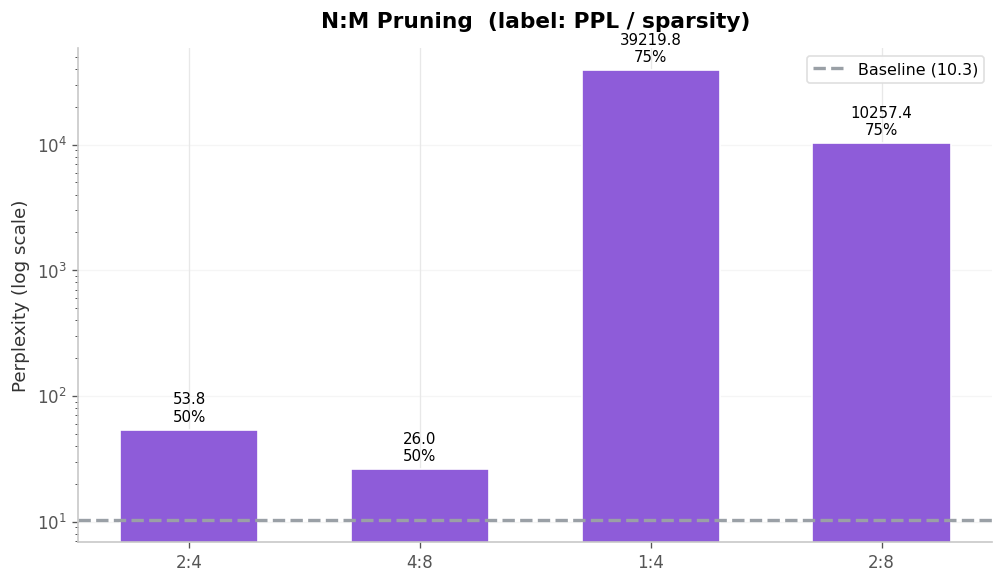

In [20]:
# N:M Pruning
####################################################################
nm_configs = [(2, 4), (4, 8), (1, 4), (2, 8)]   # (N, M): M개 중 N개 유지
####################################################################

@torch.no_grad()
def apply_nm_pruning(model, N, M):
    # 각 행을 길이 M 블록으로 나눠, 블록마다 절대값 상위 N개만 남김 (벡터화)
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and 'lm_head' not in name and 'embed' not in name:
            W = module.weight.data
            R, C = W.shape
            if C % M != 0:
                continue
            blocks = W.abs().view(R, C // M, M)
            idx = torch.topk(blocks, k=N, dim=2, largest=True).indices
            keep = torch.zeros_like(blocks, dtype=torch.bool).scatter_(2, idx, True)
            W.mul_(keep.view(R, C).to(W.dtype))

nm_results = []
for N, M in nm_configs:
    restore_weights(model, original_state)
    apply_nm_pruning(model, N, M)
    ppl = compute_perplexity(model, eval_tokens)
    nm_results.append((N, M, (1 - N/M) * 100, ppl))
    print(f"{N}:{M}  eff-sparsity {(1-N/M)*100:>3.0f}%  PPL {ppl:.2f}  (delta {ppl-baseline_ppl:+.2f})")
restore_weights(model, original_state)

fig, ax = plt.subplots(figsize=(8.5, 5))
labels = [f'{N}:{M}' for N, M, _, _ in nm_results]
bars = ax.bar(labels, [p for *_, p in nm_results], width=0.6,
              color=PALETTE['nm'], edgecolor='white', linewidth=1)
ax.axhline(baseline_ppl, color=PALETTE['baseline'], ls='--', lw=2, label=f'Baseline ({baseline_ppl:.1f})')
for b, (N, M, sp, p) in zip(bars, nm_results):
    ax.annotate(f'{p:.1f}\n{sp:.0f}%', (b.get_x() + b.get_width()/2, p),
                textcoords='offset points', xytext=(0, 5), ha='center', fontsize=9)
ax.set_ylabel('Perplexity (log scale)'); ax.set_yscale('log'); ax.set_title('N:M Pruning  (label: PPL / sparsity)')
ax.legend(); ax.grid(True, alpha=0.4, axis='y')
fig.tight_layout(); plt.show()

### 🤔 Thinking Exercises
T1) 동일 50% sparsity에서 2:4와 4:8 중 어느 쪽이 더 유리할까요? 이유는?

T2) 2:4 패턴이 GPU에서 하드웨어 가속될 수 있는 이유는?


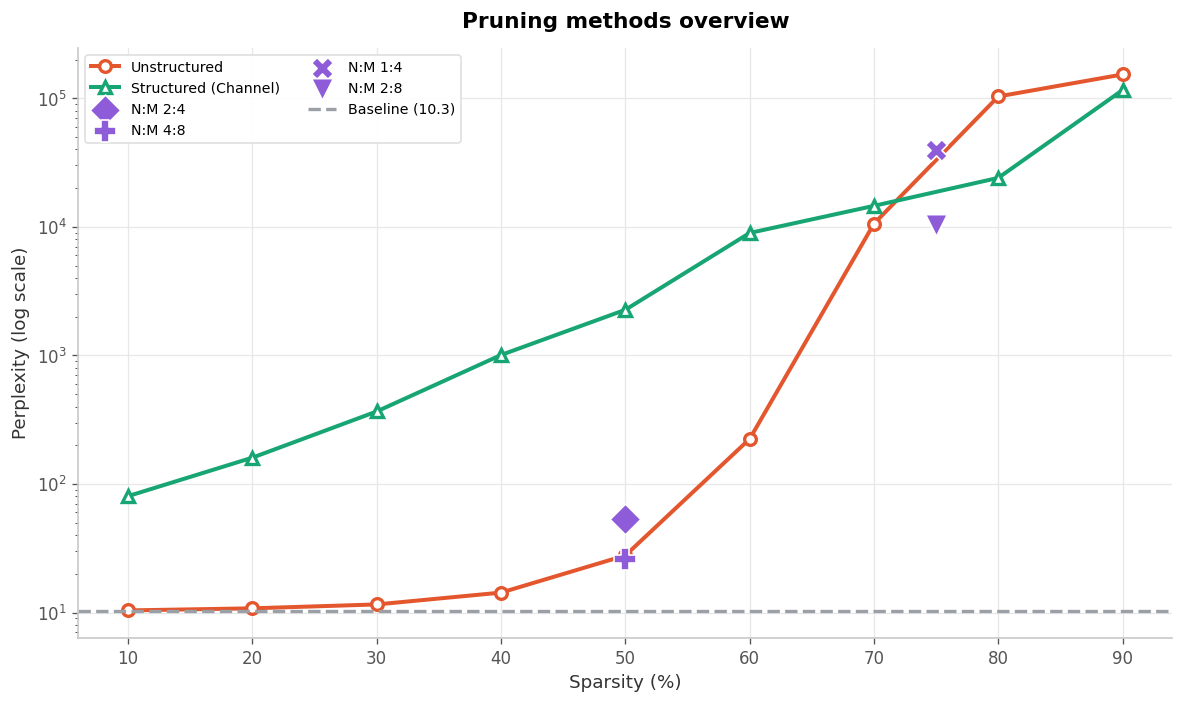

In [21]:
# Part 1 종합 비교
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sp_pct, ppl_unstruct, 'o-', color=PALETTE['unstruct'], mfc='white', mew=2, label='Unstructured')
ax.plot(sp_pct, ppl_channel, '^-', color=PALETTE['neuron'], mfc='white', mew=2, label='Structured (Channel)')
for (N, M, sp, ppl), mk in zip(nm_results, ['D', 'P', 'X', 'v']):
    ax.scatter(sp, ppl, s=170, marker=mk, color=PALETTE['nm'], edgecolor='white',
               linewidth=1, zorder=5, label=f'N:M {N}:{M}')
ax.axhline(baseline_ppl, color=PALETTE['baseline'], ls='--', lw=2, label=f'Baseline ({baseline_ppl:.1f})')
ax.set_xlabel('Sparsity (%)'); ax.set_ylabel('Perplexity (log scale)'); ax.set_yscale('log')
ax.set_title('Pruning methods overview'); ax.legend(fontsize=8.5, ncol=2)
fig.tight_layout(); plt.show()


In [22]:
# 인터랙티브: 동일 입력으로 원본 vs pruned 좌우 비교 (latency 포함)
####################################################################
prune_demo_sparsity = 0.5    # 좌우 비교 데모에 쓸 pruning 비율
####################################################################
compare_frame(lambda m: apply_magnitude_pruning(m, prune_demo_sparsity),
              f'Pruned {prune_demo_sparsity*100:.0f}%')

### 🤔 Thinking Exercises
T1) 원본 모델과 압축(50% pruned) 모델의 출력을 직접 비교해보세요. 어떤 차이가 있나요?

T2) Pruning을 적용했는데도 latency와 throughput이 (거의) 동일한 이유는 무엇인가요?


# 🔢 Part 2. Quantization

가중치를 저비트 정수 격자에 매핑해 표현합니다. 여기서는 양자화 후 다시 FP16으로 복원하는 fake quantization으로 정확도 영향을 측정합니다 (실제 저장 크기 절감은 비트폭 분석에서 이론값으로 계산).


## 2-1. Symmetric Quantization

- scale: $s = \dfrac{2\,\max(|w|)}{2^{b}-1}$
- 양자화: $Q = \mathrm{clamp}(\mathrm{round}(w/s),\, -2^{b-1},\, 2^{b-1}-1)$
- 역양자화: $\hat{w} = Q \cdot s$

실습: 채널별(행별) symmetric 양자화의 TODO를 채우세요.


In [23]:
####################################################################
sym_demo_bit = 4      # 대칭 양자화 데모 비트폭 (2, 3, 4, 8 ...)
####################################################################

@torch.no_grad()
def channelwise_symmetric_quantize(module, bit):
    W = module.weight.data
    W2 = W.view(W.size(0), -1).float()

# TODO 1: 대칭 정수 범위 [-2^(bit-1), 2^(bit-1)-1]
    q_min = -(2 ** (bit - 1))
    q_max = 2 ** (bit - 1) - 1

    a = W2.abs().amax(dim=1, keepdim=True)
    a[a == 0] = 1.0

# TODO 2: scale s = 2a / (q_max - q_min)
    s = (2 * a) / (q_max - q_min)

# TODO 3: Q = clamp(round(W2/s), q_min, q_max),  W_hat = Q * s
    Q = torch.clamp(torch.round(W2 / s), q_min, q_max)
    W_hat = Q * s

    module.weight.data.copy_(W_hat.to(W.dtype).view_as(W))

def apply_symmetric_quantization(model, bit):
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear) and 'lm_head' not in name and 'embed' not in name:
            channelwise_symmetric_quantize(m, bit)

restore_weights(model, original_state)
apply_symmetric_quantization(model, sym_demo_bit)
ppl_sym4 = compute_perplexity(model, eval_tokens)
print(f"baseline PPL : {baseline_ppl:.2f}")
print(f"sym {sym_demo_bit}-bit PPL: {ppl_sym4:.2f} (delta {ppl_sym4 - baseline_ppl:+.2f})")
restore_weights(model, original_state)


baseline PPL : 10.31
sym 4-bit PPL: 13.29 (delta +2.98)


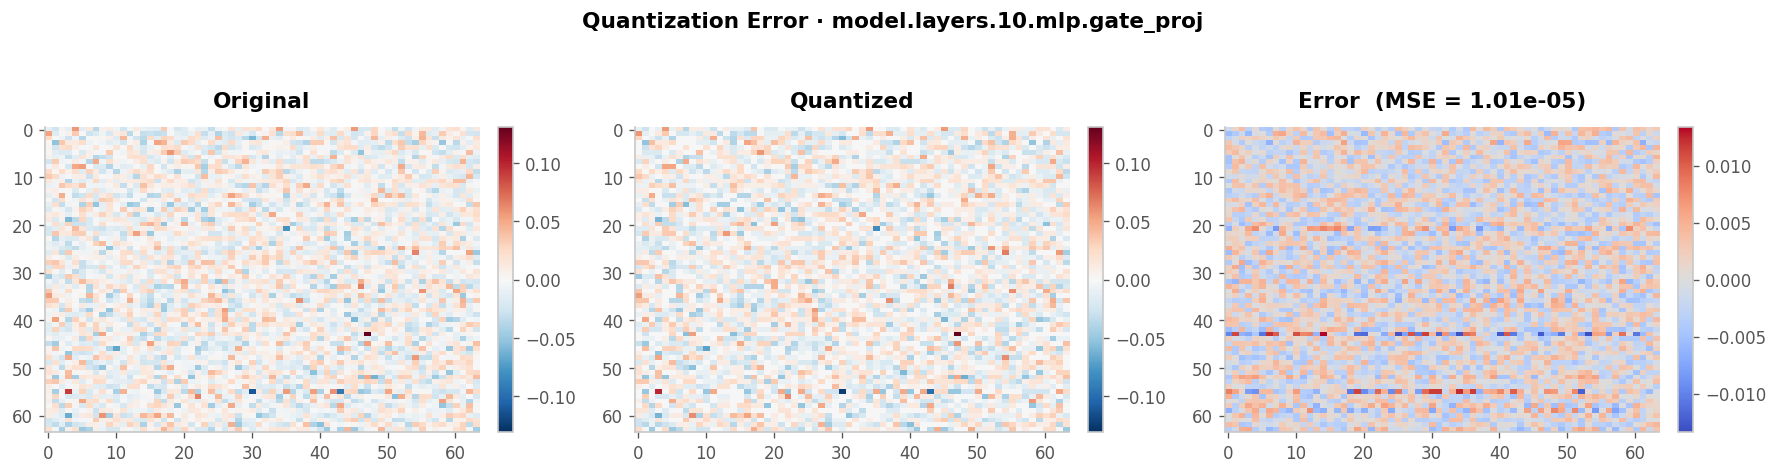

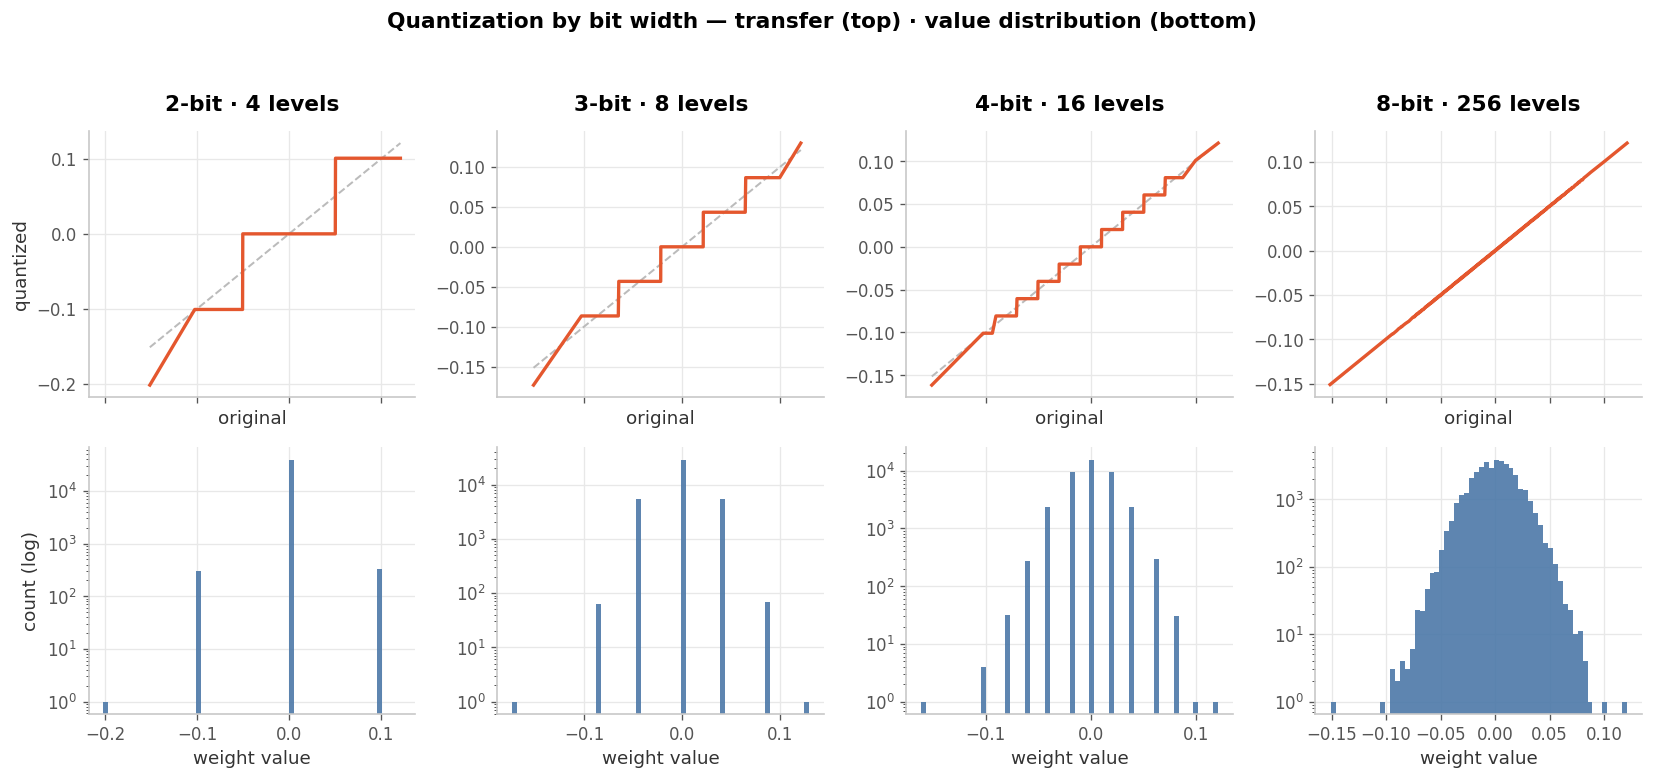

In [24]:
# 양자화 오차 히트맵 + 비트폭별 transfer/분포
####################################################################
layer_q = 'model.layers.10.mlp.gate_proj'   # 분석할 레이어
demo_bit = 4                                 # 오차 히트맵에 쓸 비트폭
bits_list_viz = (2, 3, 4, 8)                 # transfer/분포 비교 비트폭
####################################################################
for n, m in model.named_modules():
    if n == layer_q:
        w_orig_q = m.weight.detach().cpu().float()[:64, :64]
        w_orig_full = m.weight.detach().cpu().float()
apply_symmetric_quantization(model, demo_bit)
for n, m in model.named_modules():
    if n == layer_q:
        w_quant_q = m.weight.detach().cpu().float()[:64, :64]
restore_weights(model, original_state)

plot_quant_error_heatmap(w_orig_q, w_quant_q, layer_q)
plot_quant_by_bits(w_orig_full, bits_list=bits_list_viz)

In [25]:
# Symmetric bit-width sweep
####################################################################
bit_list = [2, 3, 4, 6, 8]   # 비교할 비트폭들
####################################################################
ppl_sym = []
for bit in bit_list:
    restore_weights(model, original_state)
    apply_symmetric_quantization(model, bit)
    ppl = compute_perplexity(model, eval_tokens)
    ppl_sym.append(ppl if np.isfinite(ppl) else float('nan'))
    print(f"{bit}-bit  PPL {ppl:>10.2f}  (delta {ppl-baseline_ppl:+.2f})")
restore_weights(model, original_state)

2-bit  PPL  189484.30  (delta +189473.99)
3-bit  PPL     763.28  (delta +752.97)
4-bit  PPL      13.29  (delta +2.98)
6-bit  PPL      10.35  (delta +0.04)
8-bit  PPL      10.30  (delta -0.01)


### 🤔 Thinking Exercises
T1) 양자화가 하드웨어 효율 측면에서 갖는 장점은?

T2) 어떤 가중치 분포에서 symmetric 양자화가 잘 맞을까요?


## 2-2. Asymmetric Quantization

- scale: $s = \dfrac{w_{max}-w_{min}}{2^{b}-1}$,  zero-point: $z = -\mathrm{round}(w_{min}/s)$
- 양자화: $Q=\mathrm{clamp}(\mathrm{round}(w/s)+z,\,0,\,2^{b}-1)$,  역양자화: $\hat{w}=(Q-z)\,s$


In [27]:
@torch.no_grad()
def channelwise_asymmetric_quantize(module, bit):
    W = module.weight.data
    W2 = W.view(W.size(0), -1).float()

    q_min, q_max = 0, (2 ** bit) - 1

    w_min = W2.min(dim=1, keepdim=True)[0]
    w_max = W2.max(dim=1, keepdim=True)[0]

    # TODO: 채널별 scale = (w_max - w_min) / (q_max - q_min)
    scale = (w_max - w_min) / (q_max - q_min)

    scale[scale == 0] = 1.0

    zero = q_min - torch.round(w_min / scale)

    Q = torch.clamp(torch.round(W2 / scale + zero), q_min, q_max)
    W_hat = (Q - zero) * scale

    module.weight.data.copy_(W_hat.to(W.dtype).view_as(W))

def apply_asymmetric_quantization(model, bit):
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear) and 'lm_head' not in name and 'embed' not in name:
            channelwise_asymmetric_quantize(m, bit)

ppl_asym = []

for bit in bit_list:
    restore_weights(model, original_state)
    apply_asymmetric_quantization(model, bit)

    ppl = compute_perplexity(model, eval_tokens)
    ppl_asym.append(ppl if np.isfinite(ppl) else float('nan'))

    print(f"{bit}-bit  PPL {ppl:>10.2f}  (delta {ppl-baseline_ppl:+.2f})")

restore_weights(model, original_state)

baseline PPL : 10.31
sym 4-bit PPL: 13.29 (delta +2.98)


In [ ]:
# Symmetric vs Asymmetric (2-bit는 PPL이 매우 커서 log 축 사용)
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(bit_list)); w = 0.38
ax.bar(x - w/2, ppl_sym, w, label='Symmetric', color=PALETTE['sym'], edgecolor='white', linewidth=1)
ax.bar(x + w/2, ppl_asym, w, label='Asymmetric', color=PALETTE['asym'], edgecolor='white', linewidth=1)
ax.axhline(baseline_ppl, color=PALETTE['baseline'], ls='--', lw=2, label=f'Baseline ({baseline_ppl:.1f})')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels([f'{b}-bit' for b in bit_list])
ax.set_ylabel('Perplexity (log scale)'); ax.set_title('Symmetric vs Asymmetric')
ax.legend(); ax.grid(True, alpha=0.4, axis='y', which='both')
fig.tight_layout(); plt.show()

In [ ]:
# Per-channel vs Per-tensor (granularity)
####################################################################
granularity_bits = [3, 4, 8]   # 비교할 비트폭
####################################################################

@torch.no_grad()
def apply_symmetric_pertensor(model, bit):
    q_min, q_max = -(2 ** (bit - 1)), 2 ** (bit - 1) - 1
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear) and 'lm_head' not in name and 'embed' not in name:
            W = m.weight.data
            a = W.abs().max()
            if a == 0:
                continue
            s = (2 * a) / (q_max - q_min)
            Q = torch.clamp(torch.round(W / s), q_min, q_max)
            m.weight.data.copy_((Q * s).to(W.dtype))

print(f"{'bit':>5} | {'per-channel':>12} | {'per-tensor':>11}")
for bit in granularity_bits:
    restore_weights(model, original_state); apply_symmetric_quantization(model, bit)
    pc = compute_perplexity(model, eval_tokens)
    restore_weights(model, original_state); apply_symmetric_pertensor(model, bit)
    pt = compute_perplexity(model, eval_tokens)
    print(f"{bit:>3}-bit | {pc:>12.2f} | {pt:>11.2f}")
restore_weights(model, original_state)

In [ ]:
# 비트폭별 이론적 모델 크기 (FP16 대비)
####################################################################
all_bits = [2, 3, 4, 6, 8, 16]   # 크기/PPL 비교할 비트폭
####################################################################
fp16_mb = (total_params * 16) / (8 * 1024**2)
sizes = [(total_params * b) / (8 * 1024**2) for b in all_bits]
best_ppl = [ppl_sym[bit_list.index(b)] if b in bit_list else baseline_ppl for b in all_bits]

fig, ax1 = plt.subplots(figsize=(10, 5.4))
ax1.bar(range(len(all_bits)), sizes, color=plt.cm.viridis(np.linspace(0.25, 0.85, len(all_bits))),
        edgecolor='white', linewidth=1, zorder=2)
ax1.set_xticks(range(len(all_bits))); ax1.set_xticklabels([f'{b}-bit' for b in all_bits])
ax1.set_ylabel('Model size (MB)'); ax1.set_title('Model size vs Perplexity by bit width'); ax1.grid(False)
for i, (sz, b) in enumerate(zip(sizes, all_bits)):
    ax1.text(i, sz + fp16_mb*0.012, f'{fp16_mb/sz:.1f}x', ha='center', fontsize=9,
             fontweight='bold', color='#333')
ax2 = ax1.twinx()
ax2.plot(range(len(all_bits)), best_ppl, 'o-', color=PALETTE['accent'], ms=9, mfc='white', mew=2, zorder=3)
ax2.set_ylabel('Perplexity (log scale)', color=PALETTE['accent']); ax2.set_yscale('log')
ax2.tick_params(axis='y', colors=PALETTE['accent']); ax2.grid(False)
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(PALETTE['accent'])
fig.tight_layout(); plt.show()

### 🤔 Thinking Exercises
T1) 4-bit로 크기가 4배 줄어들 때 PPL 손실은 어느 정도인가요? 온디바이스에 적절한 비트폭은?

T2) 양자화와 프루닝을 결합하면 어떤 시너지를 기대할 수 있을까요?


In [ ]:
# 인터랙티브: 동일 입력으로 원본 vs 양자화 좌우 비교 (latency 포함)
####################################################################
quant_demo_bit = 4    # 좌우 비교 데모 비트폭
####################################################################
compare_frame(lambda m: apply_symmetric_quantization(m, quant_demo_bit),
              f'Sym {quant_demo_bit}-bit')


# 🧩 Part 3. Combined Compression & Pareto

Hessian 기반 GPTQ + SparseGPT로 프루닝과 양자화를 동시에 수행하고, 레이어별 config를 직접 입력해 여러 압축 모델을 만들어 Pareto frontier를 탐색합니다.


## 3-1. GPTQ & SparseGPT

레이어별 **Hessian(2차 정보)** 을 이용해 재학습 없이 가중치를 압축하는 두 기법을 결합합니다.

- **GPTQ** — Hessian 기반으로 양자화 오차를 보정하며 한 열씩 순차 양자화 (one-shot weight quantization)
- **SparseGPT** — 동일한 Hessian 프레임워크로 프루닝을 수행해 재학습 없이 높은 sparsity 달성

두 방법을 한 Linear 레이어에서 함께 적용하면 **프루닝 + 양자화를 동시에** 수행할 수 있습니다 (아래 `CombinedCompressor`).

**논문**
- GPTQ: https://arxiv.org/abs/2210.17323
- SparseGPT: https://arxiv.org/abs/2301.00774

**참고 구현** (아래 코드는 다음 repo 기반)
```
GPTQ:      https://github.com/IST-DASLab/gptq
SparseGPT: https://github.com/IST-DASLab/sparsegpt
```


In [28]:
# 실행만 하세요 (수정 불필요): GPTQ Quantizer + SparseGPT CombinedCompressor + llm_sequential
def quantize_gptq(x, scale, zero, maxq):
    q = torch.clamp(torch.round(x / scale) + zero, 0, maxq)
    return scale * (q - zero)


class Quantizer(nn.Module):
    def __init__(self, shape=1):
        super().__init__()
        self.register_buffer('maxq', torch.tensor(0))
        self.register_buffer('scale', torch.zeros(shape))
        self.register_buffer('zero', torch.zeros(shape))

    def configure(self, bits, perchannel=False, sym=True):
        self.maxq = torch.tensor(2 ** bits - 1)
        self.perchannel = perchannel
        self.sym = sym

    def find_params(self, x, weight=False):
        dev = x.device
        self.maxq = self.maxq.to(dev)
        shape = x.shape
        if self.perchannel and weight:
            x = x.flatten(1)
        else:
            x = x.flatten().unsqueeze(0)
        tmp = torch.zeros(x.shape[0], device=dev)
        xmin = torch.minimum(x.min(1)[0], tmp)
        xmax = torch.maximum(x.max(1)[0], tmp)
        if self.sym:
            xmax = torch.maximum(torch.abs(xmin), xmax)
            neg = xmin < 0
            xmin[neg] = -xmax[neg]
        flat = (xmin == 0) & (xmax == 0)
        xmin[flat] = -1; xmax[flat] = 1
        self.scale = (xmax - xmin) / self.maxq
        if self.sym:
            self.zero = torch.full_like(self.scale, (self.maxq + 1) / 2)
        else:
            self.zero = torch.round(-xmin / self.scale)
        if not (self.perchannel and weight):
            self.scale = self.scale.repeat(shape[0])
            self.zero = self.zero.repeat(shape[0])
        self.scale = self.scale.reshape(-1, 1)
        self.zero = self.zero.reshape(-1, 1)

    def ready(self):
        return torch.all(self.scale != 0)


class CombinedCompressor:
    """SparseGPT (Hessian-based pruning) + GPTQ (quantization) for one Linear layer."""
    def __init__(self, layer):
        self.layer = layer
        self.dev = layer.weight.device
        W = layer.weight.data.clone().float()
        self.rows, self.columns = W.shape
        self.H = torch.zeros((self.columns, self.columns), device=self.dev)
        self.nsamples = 0
        self.quantizer = None

    def add_batch(self, inp):
        if inp.dim() == 3:
            inp = inp.reshape(-1, inp.shape[-1])
        elif inp.dim() == 1:
            inp = inp.unsqueeze(0)
        inp = inp.t().float()
        n = inp.shape[1]
        self.H *= self.nsamples / (self.nsamples + n)
        self.nsamples += n
        inp = math.sqrt(2.0 / self.nsamples) * inp
        self.H += inp.matmul(inp.t())

    def fasterprune(self, sparsity, prunen=0, prunem=0, blocksize=128, percdamp=0.01):
        W = self.layer.weight.data.clone().float()
        if self.quantizer is not None and not self.quantizer.ready():
            self.quantizer.find_params(W, weight=True)
        H = self.H; self.H = None
        dead = torch.diag(H) == 0
        H[dead, dead] = 1; W[:, dead] = 0
        H[torch.arange(self.columns, device=self.dev),
          torch.arange(self.columns, device=self.dev)] += percdamp * torch.mean(torch.diag(H))
        H = torch.linalg.cholesky(H)
        H = torch.cholesky_inverse(H)
        Hinv = torch.linalg.cholesky(H, upper=True)
        for i1 in range(0, self.columns, blocksize):
            i2 = min(i1 + blocksize, self.columns)
            W1 = W[:, i1:i2].clone()
            Q1 = torch.zeros_like(W1)
            Err1 = torch.zeros_like(W1)
            Hinv1 = Hinv[i1:i2, i1:i2]
            if prunen == 0 and sparsity > 0:
                metric = W1 ** 2 / (torch.diag(Hinv1).reshape(1, -1)) ** 2
                idx = min(metric.numel() - 1, int(metric.numel() * sparsity))
                thresh = torch.sort(metric.flatten())[0][idx]
                mask1 = metric <= thresh
            else:
                mask1 = torch.zeros_like(W1, dtype=torch.bool)
            for i in range(i2 - i1):
                w = W1[:, i]; d = Hinv1[i, i]
                if prunen != 0 and i % prunem == 0:
                    metric = W1[:, i:i + prunem] ** 2 / (torch.diag(Hinv1)[i:i + prunem].reshape(1, -1)) ** 2
                    j = torch.topk(metric, prunen, dim=1, largest=False)[1]
                    mask1.scatter_(1, i + j, True)
                q = w.clone(); q[mask1[:, i]] = 0
                if self.quantizer is not None:
                    q = quantize_gptq(q.unsqueeze(1), self.quantizer.scale,
                                      self.quantizer.zero, self.quantizer.maxq).flatten()
                Q1[:, i] = q
                err = (w - q) / d
                W1[:, i:] -= err.unsqueeze(1).matmul(Hinv1[i, i:].unsqueeze(0))
                Err1[:, i] = err
            W[:, i1:i2] = Q1
            W[:, i2:] -= Err1.matmul(Hinv[i1:i2, i2:])
        self.layer.weight.data = W.reshape(self.layer.weight.shape).to(self.layer.weight.data.dtype)

    def free(self):
        self.H = None
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

def resolve_config(full_name, layer_configs, default_sparsity, default_wbits):
    """Most-specific matching key wins (longest substring of the layer name)."""
    sp, wb = default_sparsity, default_wbits
    best = -1
    for key, cfg in layer_configs.items():
        if key in full_name and len(key) > best:
            best = len(key)
            sp = cfg.get('sparsity', default_sparsity)
            wb = cfg.get('wbits', default_wbits)
    return sp, wb


@torch.no_grad()
def llm_sequential(model, calib_ids, device, layer_configs, params, log=print):
    """Layer-wise GPTQ + SparseGPT compression across all decoder layers.

    Hessians for the Linear sublayers of one decoder layer are accumulated in a
    single calibration pass, then that layer is compressed before moving on, so
    peak memory stays at one decoder layer's worth of statistics.
    """
    default_sp = params.get('DEFAULT_SPARSITY', 0.0)
    default_wb = params.get('DEFAULT_WBITS', 16)
    sym = params.get('sym', False)
    perchannel = params.get('perchannel', False)
    prunen = params.get('prunen', 0)
    prunem = params.get('prunem', 0)
    percdamp = params.get('percdamp', 0.01)
    blocksize = params.get('blocksize', 128)

    model.to(device)
    layers = model.model.layers
    for li, layer in enumerate(layers):
        targets = {}
        for short, mod in layer.named_modules():
            if isinstance(mod, nn.Linear):
                full = f"model.layers.{li}.{short}"
                sp, wb = resolve_config(full, layer_configs, default_sp, default_wb)
                if sp == 0 and wb >= 16:
                    continue
                comp = CombinedCompressor(mod)
                if wb < 16:
                    comp.quantizer = Quantizer()
                    comp.quantizer.configure(bits=wb, perchannel=perchannel, sym=sym)
                targets[short] = {'comp': comp, 'mod': mod, 'sparsity': sp}
        if not targets:
            continue

        handles = []
        for t in targets.values():
            comp = t['comp']
            handles.append(t['mod'].register_forward_hook(
                lambda m, inp, out, c=comp: c.add_batch(inp[0].detach())))
        for ids in calib_ids:
            model(ids.to(device))
        for h in handles:
            h.remove()

        for short, t in targets.items():
            t['comp'].fasterprune(sparsity=t['sparsity'], prunen=prunen, prunem=prunem,
                                  percdamp=percdamp, blocksize=blocksize)
            t['comp'].free()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        log(f"  layer {li + 1}/{len(layers)} done ({len(targets)} sublayers)")


def compute_compression_stats(model, layer_configs, params):
    """Theoretical whole-model compression vs the FP16 baseline.

    Pruned weights are counted as removed; quantized weights at their bit-width;
    embeddings / lm_head stay at 16-bit.
    """
    default_sp = params.get('DEFAULT_SPARSITY', 0.0)
    default_wb = params.get('DEFAULT_WBITS', 16)
    orig_bits = comp_bits = 0
    for name, m in model.named_modules():
        if isinstance(m, (nn.Linear, nn.Embedding)):
            n = m.weight.numel()
            orig_bits += n * 16
            if isinstance(m, nn.Embedding) or 'lm_head' in name:
                comp_bits += n * 16
                continue
            sp, wb = resolve_config(name, layer_configs, default_sp, default_wb)
            comp_bits += n * (1 - sp) * wb
    ratio = orig_bits / comp_bits
    return ratio, comp_bits / 8 / 1024**2, orig_bits / 8 / 1024**2

print('compression engine ready')

compression engine ready


In [29]:
# 캘리브레이션 데이터 (Hessian 추정용)
calib_src = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='train')
calib_texts = [t for t in calib_src['text'] if len(t) > 200][:16]
calib_ids = [tokenizer(t, return_tensors='pt', truncation=True, max_length=512).input_ids
             for t in calib_texts]
print(f"calibration sequences: {len(calib_ids)}")

calibration sequences: 16


## 3-2. Config 기반 압축 실험

`params`의 기본값과 `layer_configs`의 레이어별 설정을 바꿔가며 여러 모델을 압축하세요. 각 실행은 결과를 누적 저장하고, 3-3에서 Pareto plot으로 비교합니다.

layer_configs의 key는 레이어 이름의 일부면 됩니다 (가장 구체적인 key 우선).
- `'self_attn'` → 모든 attention 투영
- `'mlp'` → 모든 MLP 투영
- `'mlp.down_proj'` → down_proj만
- `'model.layers.10'` → 10번 레이어 전체


In [30]:
# 실행만 하세요 (수정 불필요): 실험 기록 시스템 초기화
compression_experiments = []
experiment_counter = 0
last_compressed_state = None   # 마지막 압축 직후 가중치 (셀 44 데모가 항상 압축 모델을 쓰도록 보관)
_, _, baseline_size_mb = compute_compression_stats(model, {}, {})
compression_experiments.append({'number': 0, 'name': 'Baseline (FP16)', 'ratio': 1.0,
                                'size_mb': baseline_size_mb, 'ppl': baseline_ppl,
                                'ppl_delta': 0.0, 'params': {}, 'layer_configs': {}})

def run_compression_experiment(params, layer_configs, name=None):
    global experiment_counter, last_compressed_state
    restore_weights(model, original_state)
    print('compressing...')
    llm_sequential(model, calib_ids, device, layer_configs, params, log=print)
    ppl = compute_perplexity(model, eval_tokens)
    ratio, size_mb, _ = compute_compression_stats(model, layer_configs, params)
    lat = benchmark_latency(model, tokenizer, test_prompt, new_tokens=32)
    experiment_counter += 1
    rec = {'number': experiment_counter, 'name': name or f'Exp_{experiment_counter}',
           'ratio': ratio, 'size_mb': size_mb, 'ppl': ppl, 'ppl_delta': ppl - baseline_ppl,
           'decode_tok_s': lat['decode_tok_s'],
           'params': dict(params), 'layer_configs': {k: dict(v) for k, v in layer_configs.items()}}
    compression_experiments.append(rec)
    print(f"\n[#{experiment_counter}] {rec['name']}: ratio {ratio:.2f}x, size {size_mb:.0f} MB, "
          f"PPL {ppl:.2f} (delta {ppl - baseline_ppl:+.2f}), decode {lat['decode_tok_s']:.1f} tok/s")
    print(f"GPU memory: {gpu_mem():.0f} MB  (모델은 압축된 상태로 유지됩니다)")
    last_compressed_state = save_weights(model)   # 압축 직후 스냅샷 (셀 44에서 복원)
    return rec

print(f"baseline registered: {baseline_size_mb:.0f} MB, PPL {baseline_ppl:.2f}")

baseline registered: 2098 MB, PPL 10.31


In [31]:
# 여기를 수정하며 여러 번 실행하세요
####################################################################
params = {
    'DEFAULT_SPARSITY': 0.5,   # 기본 sparsity
    'DEFAULT_WBITS': 8,        # 기본 양자화 비트 (16=양자화 안 함)
    'sym': False,              # symmetric/asymmetric
    'perchannel': True,        # 채널별 scale 여부
    'prunen': 0,               # N:M 프루닝 (0이면 DEFAULT_SPARSITY 기반)
    'prunem': 0,
}
layer_configs = {
    'self_attn': {'sparsity': 0.4, 'wbits': 8},
    'mlp':       {'sparsity': 0.6, 'wbits': 4},
    # ↓ 더 세밀하게: layer/module 직접 지정도 가능 (key가 레이어 이름의 일부면 매칭, 가장 구체적 key 우선)
    # 'mlp.down_proj':                 {'sparsity': 0.7, 'wbits': 4},   # 모든 레이어의 down_proj 만
    # 'self_attn.q_proj':              {'sparsity': 0.3, 'wbits': 8},   # 모든 레이어의 q_proj 만
    # 'model.layers.0':                {'sparsity': 0.2, 'wbits': 8},   # 0번 레이어(첫 블록) 전체
    # 'model.layers.10.mlp.down_proj': {'sparsity': 0.8, 'wbits': 2},   # 특정 레이어의 특정 모듈
}
####################################################################

run_compression_experiment(params, layer_configs)

compressing...
  layer 1/22 done (7 sublayers)
  layer 2/22 done (7 sublayers)
  layer 3/22 done (7 sublayers)
  layer 4/22 done (7 sublayers)
  layer 5/22 done (7 sublayers)
  layer 6/22 done (7 sublayers)
  layer 7/22 done (7 sublayers)
  layer 8/22 done (7 sublayers)
  layer 9/22 done (7 sublayers)
  layer 10/22 done (7 sublayers)
  layer 11/22 done (7 sublayers)
  layer 12/22 done (7 sublayers)
  layer 13/22 done (7 sublayers)
  layer 14/22 done (7 sublayers)
  layer 15/22 done (7 sublayers)
  layer 16/22 done (7 sublayers)
  layer 17/22 done (7 sublayers)
  layer 18/22 done (7 sublayers)
  layer 19/22 done (7 sublayers)
  layer 20/22 done (7 sublayers)
  layer 21/22 done (7 sublayers)
  layer 22/22 done (7 sublayers)


[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=32) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[#1] Exp_1: ratio 4.08x, size 514 MB, PPL 28.36 (delta +18.05), decode 32.8 tok/s
GPU memory: 2108 MB  (모델은 압축된 상태로 유지됩니다)


{'number': 1,
 'name': 'Exp_1',
 'ratio': 4.081712062256814,
 'size_mb': 513.9999999999993,
 'ppl': 28.35870933532715,
 'ppl_delta': 18.049172401428223,
 'decode_tok_s': 32.834968585831554,
 'params': {'DEFAULT_SPARSITY': 0.5,
  'DEFAULT_WBITS': 8,
  'sym': False,
  'perchannel': True,
  'prunen': 0,
  'prunem': 0},
 'layer_configs': {'self_attn': {'sparsity': 0.4, 'wbits': 8},
  'mlp': {'sparsity': 0.6, 'wbits': 4}}}

## 3-3. Pareto Frontier

x축 압축률(클수록 좋음), y축 Perplexity(작을수록 좋음). 어떤 실험도 더 좋게 지배하지 못하는 점들이 Pareto optimal입니다.


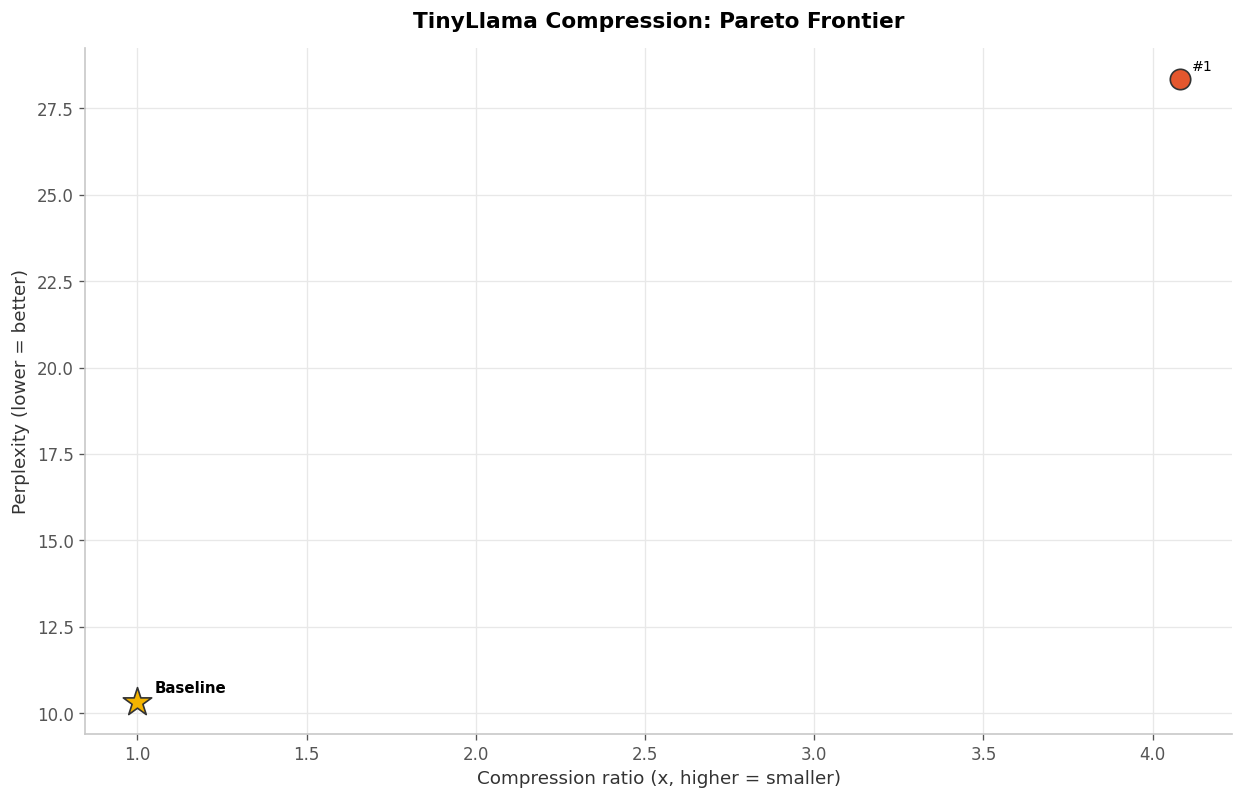


  # | name               |   ratio |  size(MB) |      PPL | status
----------------------------------------------------------------------
  0 | Baseline (FP16)    |   1.00x |      2098 |    10.31 | baseline
  1 | Exp_1              |   4.08x |       514 |    28.36 | pareto


In [32]:
def pareto_mask(ratios, ppls):
    n = len(ratios); eff = [True] * n
    for i in range(n):
        for j in range(n):
            if j != i and ratios[j] >= ratios[i] and ppls[j] <= ppls[i] and \
               (ratios[j] > ratios[i] or ppls[j] < ppls[i]):
                eff[i] = False; break
    return eff

def plot_pareto():
    if len(compression_experiments) <= 1:
        print('실험을 먼저 실행하세요.'); return
    exps = sorted(compression_experiments, key=lambda e: e['number'])
    ratios = [e['ratio'] for e in exps]; ppls = [e['ppl'] for e in exps]
    eff = pareto_mask(ratios, ppls)

    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    pe = sorted([e for i, e in enumerate(exps) if eff[i] and e['number'] != 0], key=lambda e: e['ratio'])
    if len(pe) > 1:
        ax.plot([e['ratio'] for e in pe], [e['ppl'] for e in pe], '--', color=PALETTE['pareto'],
                alpha=0.6, lw=2, zorder=2, label='Pareto frontier')
    for i, e in enumerate(exps):
        if e['number'] == 0:
            ax.scatter(e['ratio'], e['ppl'], s=320, c='#f4b400', marker='*',
                       edgecolor='#333', linewidth=1, zorder=6)
            ax.annotate('Baseline', (e['ratio'], e['ppl']), xytext=(10, 6),
                        textcoords='offset points', fontsize=9, fontweight='bold')
        else:
            on = eff[i]
            ax.scatter(e['ratio'], e['ppl'], s=150 if on else 90,
                       c=PALETTE['pareto'] if on else PALETTE['dom'],
                       edgecolor='#333' if on else '#999', linewidth=1, zorder=5 if on else 3)
            ax.annotate(f"#{e['number']}", (e['ratio'], e['ppl']), xytext=(7, 5),
                        textcoords='offset points', fontsize=8.5)
    ax.set_xlabel('Compression ratio (x, higher = smaller)')
    ax.set_ylabel('Perplexity (lower = better)')
    ax.set_title('TinyLlama Compression: Pareto Frontier')
    if len(pe) > 1:
        ax.legend()
    fig.tight_layout(); plt.show()

    print(f"\n{'#':>3} | {'name':<18} | {'ratio':>7} | {'size(MB)':>9} | {'PPL':>8} | status")
    print('-' * 70)
    for i, e in enumerate(exps):
        status = 'baseline' if e['number'] == 0 else ('pareto' if eff[i] else '')
        print(f"{e['number']:>3} | {e['name']:<18} | {e['ratio']:>6.2f}x | {e['size_mb']:>9.0f} | "
              f"{e['ppl']:>8.2f} | {status}")

plot_pareto()


## 3-4. 실험 데이터 관리

Pareto plot이 지저분해지면 아래 유틸로 불필요한 실험을 정리하세요. 정리 후 `plot_pareto()`를 다시 실행하면 반영됩니다. (baseline `#0`은 항상 보존됩니다.)

- `remove_experiment(n)` / `remove_experiments([..])` — 번호로 제거
- `remove_experiments_by_condition(max_ppl=, min_ratio=)` — 조건으로 제거
- `remove_dominated_experiments()` — Pareto 최적이 아닌 실험 일괄 제거
- `list_experiments()` / `show_experiment_details(n)` — 조회
- `reset_experiments()` — baseline만 남기고 초기화


In [33]:
# 실험 데이터 관리 — Pareto plot에서 불필요한 실험을 정리하는 유틸
# (압축 엔진/기록 시스템과 분리. 정리 후 plot_pareto() 를 다시 실행하면 반영됩니다.)

def remove_experiment(number):
    """실험 1개를 번호로 제거합니다. (baseline #0은 제거 불가)"""
    global compression_experiments
    if number == 0:
        print('baseline(#0)은 제거할 수 없습니다.'); return
    before = len(compression_experiments)
    compression_experiments = [e for e in compression_experiments if e['number'] != number]
    if len(compression_experiments) < before:
        print(f'실험 #{number} 제거 ({len(compression_experiments)}개 남음)')
    else:
        print(f'실험 #{number}을(를) 찾을 수 없습니다.')

def remove_experiments(numbers):
    """여러 실험을 한 번에 제거합니다. 예: remove_experiments([2, 4, 5])"""
    for n in numbers:
        remove_experiment(n)

def remove_experiments_by_condition(max_ppl=None, min_ratio=None):
    """조건을 만족하는 실험을 제거합니다.
    max_ppl  : PPL이 이 값보다 큰(나쁜) 실험 제거
    min_ratio: 압축률(ratio)이 이 값보다 작은 실험 제거
    """
    global compression_experiments
    removed = []
    for e in compression_experiments:
        if e['number'] == 0:
            continue
        hit = (max_ppl is not None and e['ppl'] > max_ppl) or (min_ratio is not None and e['ratio'] < min_ratio)
        if hit:
            removed.append(e)
    for e in removed:
        compression_experiments.remove(e)
        print(f"제거: #{e['number']} (PPL {e['ppl']:.2f}, ratio {e['ratio']:.2f}x)")
    print(f"{len(removed)}개 제거, {len(compression_experiments)}개 남음")

def remove_dominated_experiments():
    """Pareto 최적이 아닌(다른 실험에 지배당하는) 실험을 모두 제거합니다. baseline은 유지.
    Pareto frontier만 깔끔하게 남기고 싶을 때 사용하세요. (pareto_mask는 3-3 셀에서 정의)"""
    global compression_experiments
    exps = sorted(compression_experiments, key=lambda e: e['number'])
    eff = pareto_mask([e['ratio'] for e in exps], [e['ppl'] for e in exps])
    keep = [e for i, e in enumerate(exps) if eff[i] or e['number'] == 0]
    removed = len(exps) - len(keep)
    compression_experiments = keep
    print(f'지배당하는 실험 {removed}개 제거, {len(keep)}개 남음 (baseline 포함)')

def list_experiments():
    """저장된 모든 실험 목록을 출력합니다."""
    if len(compression_experiments) <= 1:
        print('저장된 실험이 없습니다 (baseline 제외).')
    print(f"{'#':>3} | {'name':<18} | {'ratio':>7} | {'PPL':>8}")
    print('-' * 46)
    for e in sorted(compression_experiments, key=lambda x: x['number']):
        mark = ' *' if e['number'] == 0 else ''
        print(f"{e['number']:>3} | {e['name']:<18} | {e['ratio']:>6.2f}x | {e['ppl']:>8.2f}{mark}")

def show_experiment_details(number):
    """특정 실험의 상세 설정(params / layer_configs)을 출력합니다."""
    e = next((x for x in compression_experiments if x['number'] == number), None)
    if e is None:
        print(f'실험 #{number}을(를) 찾을 수 없습니다.'); return
    print(f"=== 실험 #{number}: {e['name']} ===")
    print(f"ratio {e['ratio']:.2f}x | size {e['size_mb']:.0f} MB | "
          f"PPL {e['ppl']:.2f} (delta {e['ppl_delta']:+.2f})")
    if e['params']:
        print('params:')
        for k, v in e['params'].items():
            print(f"  - {k}: {v}")
    if e['layer_configs']:
        print('layer_configs:')
        for layer, cfg in e['layer_configs'].items():
            print(f"  - {layer}: {cfg}")

def reset_experiments():
    """baseline(#0)만 남기고 모든 실험을 초기화합니다."""
    global compression_experiments, experiment_counter
    compression_experiments = [e for e in compression_experiments if e['number'] == 0]
    experiment_counter = 0
    print('baseline만 남기고 초기화했습니다.')

print('실험 데이터 관리 유틸 준비 완료')

실험 데이터 관리 유틸 준비 완료


In [34]:
# 사용 예시 (필요한 줄의 주석을 풀어 실행하세요)
# list_experiments()                              # 저장된 실험 목록
# show_experiment_details(2)                      # 2번 실험 상세 설정
# remove_experiment(3)                            # 3번 실험 제거
# remove_experiments([2, 4, 5])                   # 여러 개 한 번에 제거
# remove_experiments_by_condition(max_ppl=50)     # PPL 50 초과(나쁜) 실험 제거
# remove_experiments_by_condition(min_ratio=2.0)  # 압축률 2x 미만 실험 제거
# remove_dominated_experiments()                  # Pareto 최적 아닌 실험 모두 제거
# reset_experiments()                             # baseline만 남기고 초기화
# plot_pareto()                                   # 정리 후 Pareto plot 다시 그리기
